<a href="https://colab.research.google.com/github/arunabhachanda/predictive-maintenance-ml-dl/blob/main/Predictive_Maintenance_Phase2_NASA_CMAPSS_RUL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# Preprocessing & Evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


##Dataset Briefing — NASA CMAPSS (FD001)

### What is CMAPSS?
CMAPSS stands for **Commercial Modular Aero-Propulsion System Simulation** — a NASA simulation
of turbofan jet engines running under real operating conditions until they fail.
Each engine starts in a healthy state and gradually degrades due to internal faults until failure.

### Dataset Structure
The dataset has 4 subsets (FD001 to FD004). We use **FD001** — the cleanest subset:
single operating condition, single fault mode — ideal for learning RUL prediction.

| File | Description |
|------|-------------|
| train_FD001.txt | 100 engines run to failure — full degradation history |
| test_FD001.txt | 100 engines stopped at some point before failure |
| RUL_FD001.txt | Ground truth — how many cycles each test engine had remaining |

### What Each Row Represents
Each row = one engine at one point in time, with 26 columns:
- **engine_id** — which engine (1 to 100)
- **cycle** — time step (starts at 1, ends at failure)
- **setting_1, setting_2, setting_3** — operational settings
- **sensor_1 to sensor_21** — 21 sensor measurements (temperature, pressure, speed etc.)

### Our Goal — Remaining Useful Life (RUL) Prediction
Given the sensor history of an engine up to cycle T, predict how many cycles remain before failure.
This is a **regression problem** solved with **LSTM/GRU** — because sensor readings over time
tell a story of gradual degradation that sequential models are specifically designed to learn.

### Why LSTM/GRU and Not XGBoost?
In Phase 1, each row was independent — the model looked at one snapshot at a time.
Here, the ORDER of rows matters — an engine at cycle 150 with rising temperature readings
is very different from one at cycle 150 with stable readings. LSTMs capture this
temporal dependency by maintaining memory across sequences.

### Key Challenges
- **No explicit RUL labels in training data** — must be engineered from cycle data
- **21 sensors — not all are informative** — some sensors show zero variance, will be dropped
- **Sequences of different lengths** — each engine has a different lifespan before failure
- **Piecewise linear RUL assumption** — engine is assumed healthy for early cycles,
  then degrades linearly toward failure (a common and effective simplification)

### Real-World Relevance
| Industry | Application |
|----------|------------|
| Aviation | Predict jet engine component lifespan — Lufthansa, Airbus |
| Logistics | Predict delivery vehicle engine health — Amazon, DHL |
| Automotive | Predict engine wear during R&D testing — Mercedes-Benz, BMW |
| Energy | Predict turbine degradation — Siemens, GE |
| Data Centres | Predict cooling system hardware life — Google, AWS |

##**Dataset loading**

In [5]:
from google.colab import files

print("Please upload train_FD001.txt, test_FD001.txt and RUL_FD001.txt")
uploaded = files.upload()

Please upload train_FD001.txt, test_FD001.txt and RUL_FD001.txt


Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [7]:
import io

# Column names
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
setting_cols = ['setting_1', 'setting_2', 'setting_3']
col_names = ['engine_id', 'cycle', *setting_cols, *sensor_cols]

# Load from uploaded files
train_df = pd.read_csv(io.BytesIO(uploaded['train_FD001.txt']),
                        sep='\s+', header=None, names=col_names)
test_df = pd.read_csv(io.BytesIO(uploaded['test_FD001.txt']),
                       sep='\s+', header=None, names=col_names)
rul_df = pd.read_csv(io.BytesIO(uploaded['RUL_FD001.txt']),
                      header=None, names=['RUL'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)
print("\nFirst 5 rows:")
train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)

First 5 rows:


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


##Observations

| File | Rows | Columns | Description |
|------|------|---------|-------------|
| train_FD001.txt | 20,631 | 26 | 100 engines run to failure — full degradation history |
| test_FD001.txt | 13,096 | 26 | 100 engines stopped before failure — partial history |
| RUL_FD001.txt | 100 | 1 | Ground truth RUL for each test engine |

- 26 columns = engine_id + cycle + 3 operational settings + 21 sensor readings
- FD001: single operating condition (setting_3 = 100.0 constant across all rows)
- No header in raw files — column names manually assigned
- Dataset loaded via manual upload (Kaggle: behrad3d/nasa-cmaps)

### What Each Row Represents
Each row = one engine at one specific point in time (one cycle).
Think of it as a snapshot — every cycle, all 21 sensors record the engine's current health state.
Stacking all rows for a single engine gives its complete degradation story from healthy to failure.

Example — Engine 1:
- Row 1: Engine 1, Cycle 1 → healthy, all sensors normal
- Row 2: Engine 1, Cycle 2 → still healthy, tiny sensor shifts
- ...
- Row N: Engine 1, Cycle N → failure point, sensors show maximum stress

The LSTM reads these rows IN SEQUENCE to learn the pattern of degradation over time,
which is why row ORDER matters here — unlike Phase 1 where each row was independent.

### Column Reference
| Column | Description |
|--------|-------------|
| engine_id | Which engine (1–100) |
| cycle | Time step — starts at 1, ends at failure cycle |
| setting_1, 2, 3 | Operational settings (constant in FD001) |
| sensor_1 to sensor_21 | 21 sensor measurements — temperature, pressure, speed etc. |

- Next step: EDA — engine lifespan distribution and sensor variance analysis

##**EDA**

=== Training Data Info ===
Number of engines: 100
Total cycles: 20631

Engine lifespan (cycles):
  Min:    128
  Max:    362
  Mean:   206.3
  Median: 199.0


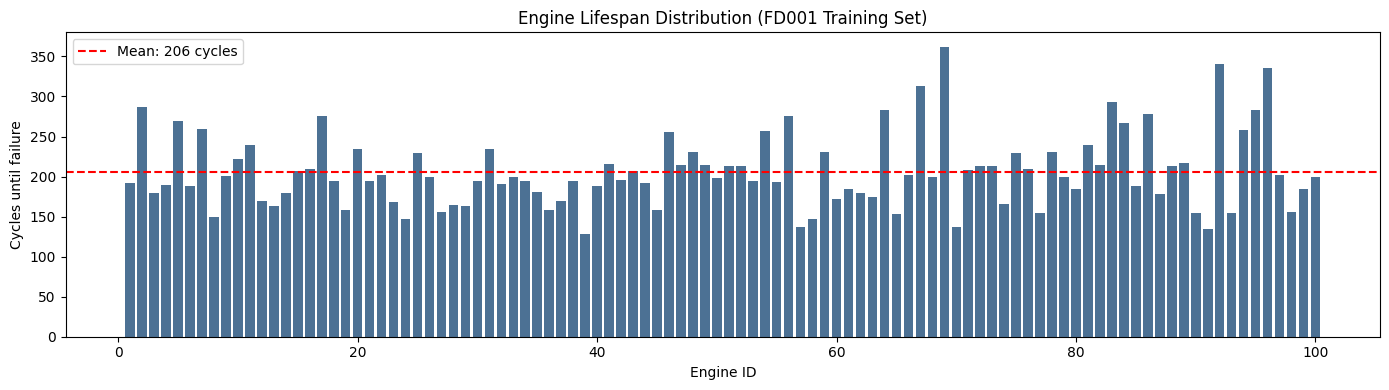


=== Missing Values ===
0 missing values in training data


In [8]:
print("=== Training Data Info ===")
print(f"Number of engines: {train_df['engine_id'].nunique()}")
print(f"Total cycles: {len(train_df)}")

# Engine lifespan stats
engine_life = train_df.groupby('engine_id')['cycle'].max()
print(f"\nEngine lifespan (cycles):")
print(f"  Min:    {engine_life.min()}")
print(f"  Max:    {engine_life.max()}")
print(f"  Mean:   {engine_life.mean():.1f}")
print(f"  Median: {engine_life.median()}")

# Visualise engine lifespans
plt.figure(figsize=(14, 4))
plt.bar(engine_life.index, engine_life.values, color='#1F4E79', alpha=0.8)
plt.axhline(engine_life.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {engine_life.mean():.0f} cycles')
plt.xlabel('Engine ID')
plt.ylabel('Cycles until failure')
plt.title('Engine Lifespan Distribution (FD001 Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

# Check missing values
print("\n=== Missing Values ===")
print(train_df.isnull().sum().sum(), "missing values in training data")

##Engine Lifespan Analysis

- **Engines:** 100 | **Total cycles:** 20,631 | **Missing values:** 0
- **Lifespan range:** 128 (min) to 362 (max) cycles
- **Mean:** 206.3 cycles | **Median:** 199.0 cycles

**Key insights:**
- High lifespan variance (128–362) — LSTM sequence window must fit shortest engine
- Mean ≈ Median → fairly symmetric distribution, no extreme outliers
- No pattern by engine ID — lifespan variation is random, not batch-related
- **Sequence window decision:** 30–50 cycles — short enough for all engines, long enough to capture degradation trend
- Next step: Sensor variance analysis — identify and drop uninformative sensors

=== Sensor Standard Deviations ===
sensor_1      0.0000
sensor_2      0.5001
sensor_3      6.1311
sensor_4      9.0006
sensor_5      0.0000
sensor_6      0.0014
sensor_7      0.8851
sensor_8      0.0710
sensor_9     22.0829
sensor_10     0.0000
sensor_11     0.2671
sensor_12     0.7376
sensor_13     0.0719
sensor_14    19.0762
sensor_15     0.0375
sensor_16     0.0000
sensor_17     1.5488
sensor_18     0.0000
sensor_19     0.0000
sensor_20     0.1807
sensor_21     0.1083


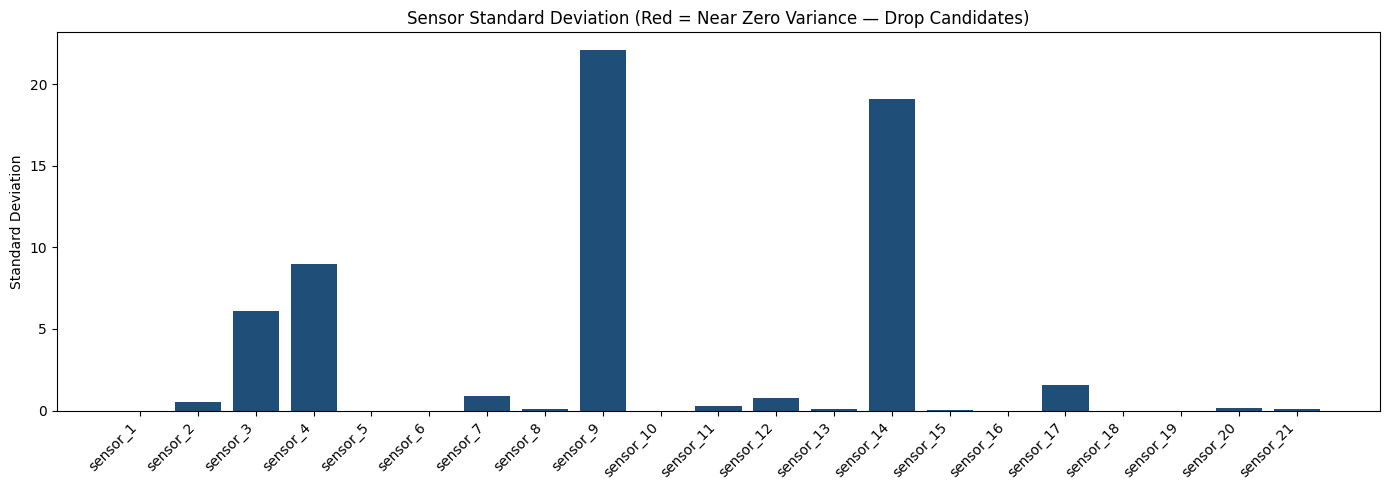


Sensors to drop (std < 0.01): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [9]:
# Check variance of each sensor across all training data
sensor_std = train_df[sensor_cols].std()

print("=== Sensor Standard Deviations ===")
print(sensor_std.round(4).to_string())

# Visualise
plt.figure(figsize=(14, 5))
colors = ['#e74c3c' if v < 0.01 else '#1F4E79' for v in sensor_std.values]
plt.bar(sensor_std.index, sensor_std.values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Sensor Standard Deviation (Red = Near Zero Variance — Drop Candidates)')
plt.ylabel('Standard Deviation')
plt.tight_layout()
plt.show()

# Identify low variance sensors
drop_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print("\nSensors to drop (std < 0.01):", drop_sensors)

##Sensor Variance Analysis

- 21 sensors total — not all are informative
- **Zero variance (std = 0.0):** sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19
  → Record identical values every cycle — zero predictive value, dropped
- **Near-zero variance (std < 0.01):** sensor_6 (std = 0.0014)
  → Effectively constant — dropped
- **Total dropped: 7 sensors** | **Remaining: 14 informative sensors**
- Most informative: sensor_9 (22.08), sensor_14 (19.08), sensor_4 (9.00), sensor_3 (6.13)
- Next step: Engineer RUL labels + visualise sensor degradation trends over time

In [10]:
# Drop uninformative sensors
drop_sensors = ['sensor_1', 'sensor_5', 'sensor_6',
                'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
drop_cols = ['setting_1', 'setting_2', 'setting_3'] + drop_sensors

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print("Train shape after dropping:", train_df.shape)
print("Remaining features:", train_df.columns.tolist())

# Engineer RUL for training data
# RUL = max cycle for that engine - current cycle
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df = train_df.drop(columns=['max_cycle'])

# Apply piecewise linear RUL cap at 125 cycles
# (engine assumed healthy before this threshold — degradation only after)
RUL_CAP = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

print("\nRUL column added. Sample:")
print(train_df[['engine_id', 'cycle', 'RUL']].head(10))
print("\nRUL distribution:")
print(train_df['RUL'].describe().round(2))

Train shape after dropping: (20631, 16)
Remaining features: ['engine_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

RUL column added. Sample:
   engine_id  cycle  RUL
0          1      1  125
1          1      2  125
2          1      3  125
3          1      4  125
4          1      5  125
5          1      6  125
6          1      7  125
7          1      8  125
8          1      9  125
9          1     10  125

RUL distribution:
count    20631.00
mean        86.83
std         41.67
min          0.00
25%         51.00
50%        103.00
75%        125.00
max        125.00
Name: RUL, dtype: float64


##Sensor Dropping & RUL Engineering

**Dropped columns:** setting_1, setting_2, setting_3 (constant in FD001) +
sensor_1, 5, 6, 10, 16, 18, 19 (zero/near-zero variance)
**Remaining shape:** 20,631 × 16 (engine_id + cycle + 14 sensors)

**RUL Label Engineering:**
- Formula: RUL = max_cycle_for_engine - current_cycle

**Why We Cap RUL at 125 Cycles — The Core Logic:**

Imagine two engines:
- Engine A has a total lifespan of 300 cycles
- Engine B has a total lifespan of 150 cycles

At cycle 10, both engines look completely identical — sensors show normal healthy readings.
Without a cap, we'd label Engine A's cycle 10 as RUL = 290 and Engine B's cycle 10 as RUL = 140.
But the sensor data looks THE SAME at both points. We're asking the model to predict
two very different numbers from identical input — this is contradictory and confuses the model.

The cap solves this by saying:
→ "If the engine has more than 125 cycles remaining, label it as RUL = 125"
→ "Only start counting down once the engine enters its degradation zone (RUL < 125)"

This way the model learns: "healthy sensor readings = 125, degrading readings = count down to 0"
instead of trying to distinguish between RUL = 290 and RUL = 140 from identical sensor data.

This is called a **Piecewise Linear RUL** assumption:
- Phase 1 (healthy): RUL stays flat at 125 — no degradation signal yet
- Phase 2 (degrading): RUL counts down linearly from 125 to 0

**RUL Distribution after capping:**
- Min: 0 (failure point) | Max: 125 (healthy/capped)
- Mean: 86.83 | Median: 103.0
- 25% of cycles in healthy zone (RUL = 125) — cap working correctly
- Next step: Visualise sensor degradation trends + normalise + build sequences

##**Visualise Sensor Degradation Trends**

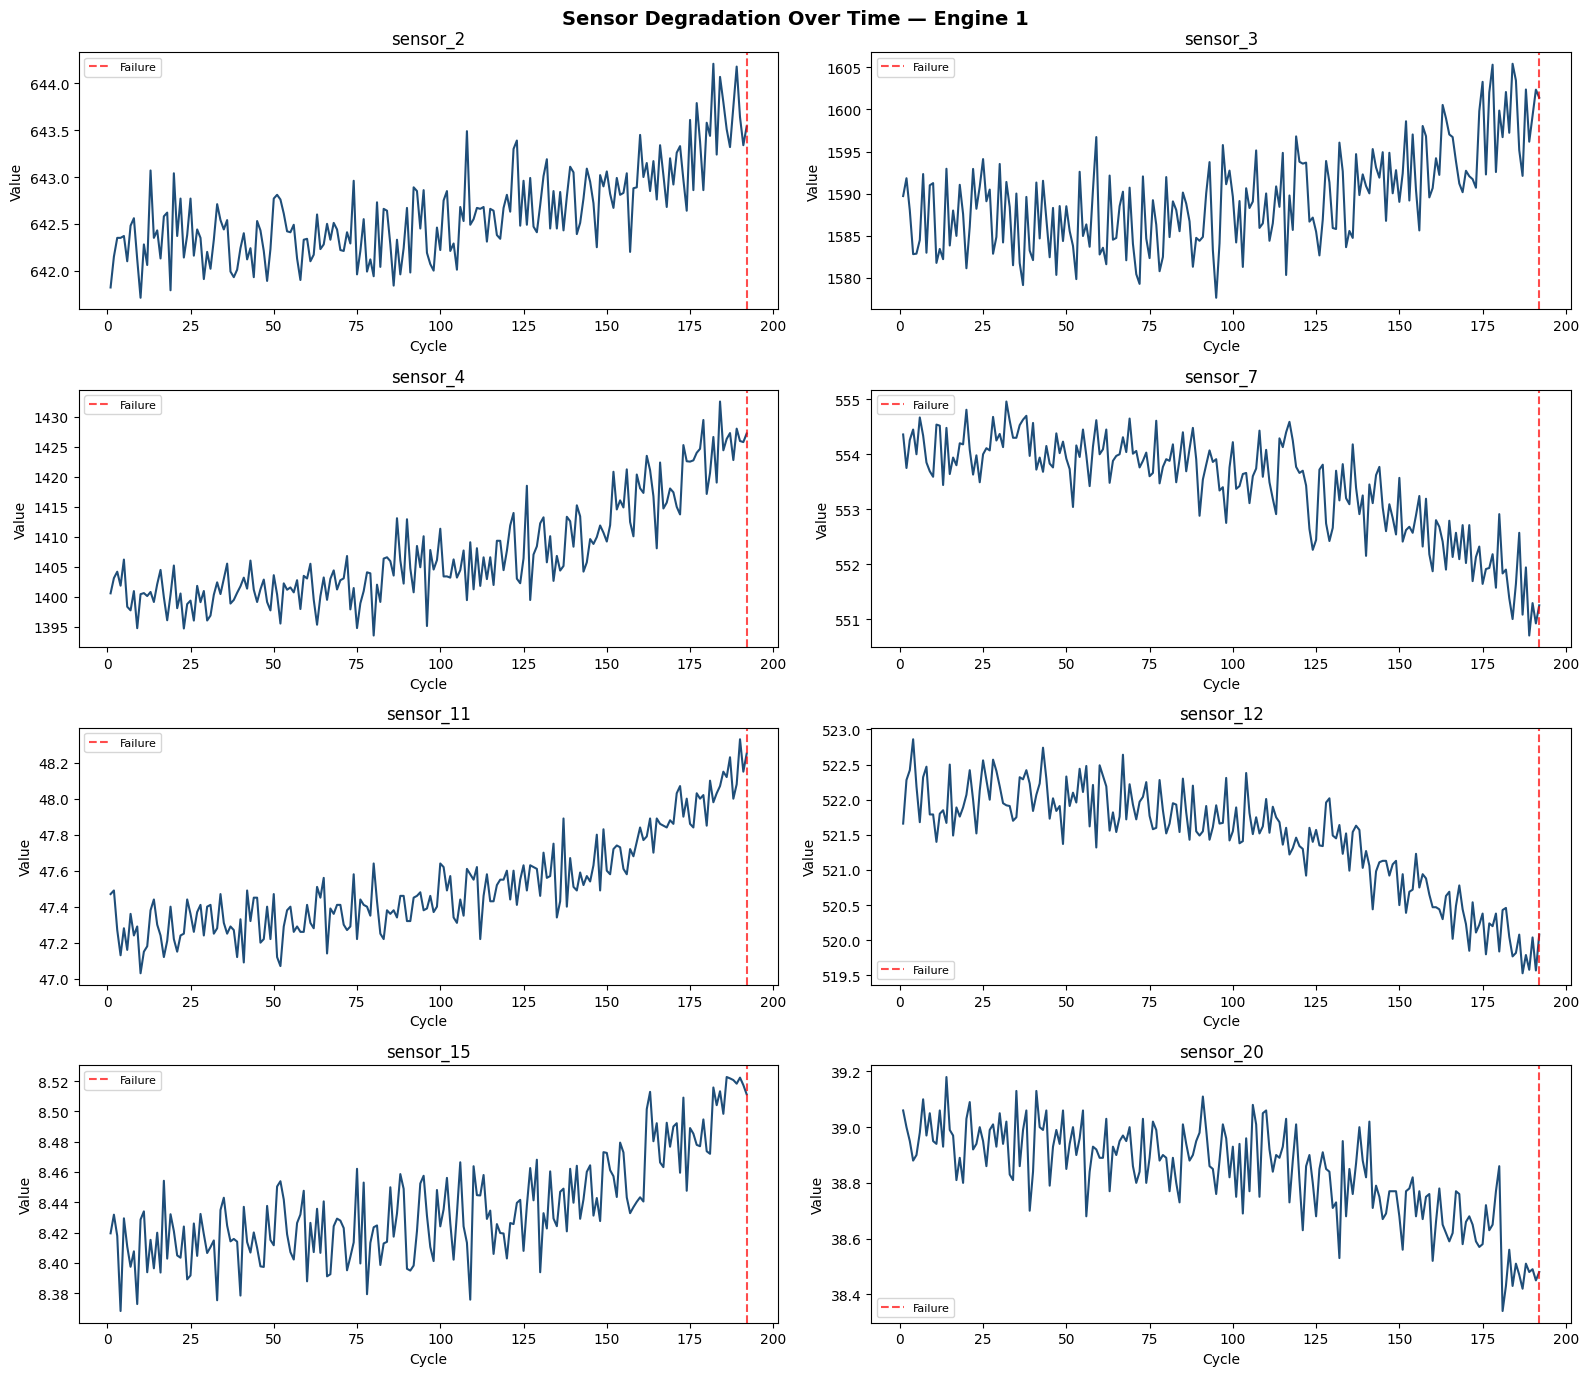

In [11]:
# Plot sensor degradation for a sample engine
sample_engine = train_df[train_df['engine_id'] == 1]

# Select most informative sensors to visualise
plot_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
                'sensor_11', 'sensor_12', 'sensor_15', 'sensor_20']

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Sensor Degradation Over Time — Engine 1', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, sensor in enumerate(plot_sensors):
    axes[i].plot(sample_engine['cycle'], sample_engine[sensor],
                 color='#1F4E79', linewidth=1.5)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')
    axes[i].axvline(sample_engine['cycle'].max(), color='red',
                    linestyle='--', alpha=0.7, label='Failure')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

##Sensor Degradation Visualisation (Engine 1)

All 8 visualised sensors show clear directional trends toward failure (red dashed line):

| Sensor | Trend | Interpretation |
|--------|-------|---------------|
| sensor_2 | Increasing ↑ | Temperature/pressure rising as engine degrades |
| sensor_3 | Increasing ↑ | Noisy but clear upward degradation signal |
| sensor_4 | Increasing ↑ | Very clean trend — one of the strongest signals |
| sensor_7 | Decreasing ↓ | Inverse signal — drops as engine degrades |
| sensor_11 | Increasing ↑ | Clean upward trend — excellent predictor |
| sensor_12 | Decreasing ↓ | Clear downward trend toward failure |
| sensor_15 | Increasing ↑ | Gradual upward trend — useful signal |
| sensor_20 | Decreasing ↓ | Steady decline toward failure |

**Key conclusion:** All sensors show systematic change as the engine approaches failure.
This confirms the dataset has strong learnable signals for the LSTM.
The noise visible in each plot is real sensor measurement noise — the LSTM will learn
to identify the underlying degradation trend through this noise.
This is precisely the type of pattern LSTMs are architecturally designed to model.

- Next step: Normalise sensor values + build sliding window sequences for LSTM input

##**Normalisation & Sequence Building**

In [13]:
# Define feature columns
feature_cols = [col for col in train_df.columns
                if col not in ['engine_id', 'cycle', 'RUL']]
print("Feature columns:", feature_cols)
print("Number of features:", len(feature_cols))

# Normalise using MinMaxScaler (fit on train, transform both)
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print("\nNormalisation complete. Sample scaled values:")
print(train_df[feature_cols].head(3).round(4))

# Build sliding window sequences
SEQUENCE_LENGTH = 50

def build_sequences(df, sequence_length, feature_cols):
    X, y = [], []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id]
        features = engine_data[feature_cols].values
        rul = engine_data['RUL'].values

        # Sliding window — for each valid position, take last `sequence_length` cycles
        for i in range(sequence_length, len(features) + 1):
            X.append(features[i - sequence_length:i])
            y.append(rul[i - 1])

    return np.array(X), np.array(y)

X_train, y_train = build_sequences(train_df, SEQUENCE_LENGTH, feature_cols)
print("\nTraining sequences shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Sequence interpretation: (samples, timesteps, features)")

Feature columns: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of features: 14

Normalisation complete. Sample scaled values:
   sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  sensor_11  \
0    0.1837    0.4068    0.3098    0.7262    0.2424    0.1098      0.369   
1    0.2831    0.4530    0.3526    0.6280    0.2121    0.1002      0.381   
2    0.3434    0.3695    0.3705    0.7101    0.2727    0.1400      0.250   

   sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  sensor_20  sensor_21  
0     0.6333     0.2059     0.1996     0.3640     0.3333     0.7132     0.7247  
1     0.7655     0.2794     0.1628     0.4113     0.3333     0.6667     0.7310  
2     0.7953     0.2206     0.1718     0.3574     0.1667     0.6279     0.6214  

Training sequences shape: (15731, 50, 14)
Training labels shape: (15731,)
Sequence interpretation: (sample

##Summary

**Normalisation:**
- MinMaxScaler applied — all sensor values scaled to [0, 1]. LSTM gates use sigmoid activations internally which work best with values in [0,1]. MinMaxScaler maps all sensor values to [0,1] which aligns perfectly with this. StandardScaler produces values centred at 0 with negative values, which is slightly less optimal for LSTMs.
- Fit on training data only, transform applied to both train and test
- Why MinMaxScaler over StandardScaler? LSTM gates use sigmoid activations
  internally which work best with values in [0,1]. StandardScaler produces
  negative values which are slightly less optimal for LSTMs.

**Sequence Building — Sliding Window Approach:**
- Sequence length: 50 cycles
- For each valid position, take the last 50 cycles as input, RUL at last cycle as label

Example for Engine 1:
  cycles 1–50  → input sequence 1, label = RUL at cycle 50
  cycles 2–51  → input sequence 2, label = RUL at cycle 51
  cycles 3–52  → input sequence 3, label = RUL at cycle 52

**Output shapes:**
- X_train: (15,731, 50, 14) → 15,731 sequences × 50 timesteps × 14 sensors
- y_train: (15,731,) → one RUL value per sequence
- ~4,900 rows lost (first 49 cycles of each engine can't form full sequences) — expected

- Next step: Build test sequences + LSTM model architecture

##**Build Test Sequences**

In [14]:
def build_test_sequences(df, sequence_length, feature_cols):
    X_test = []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id]
        features = engine_data[feature_cols].values

        # Take only the last `sequence_length` cycles
        if len(features) >= sequence_length:
            X_test.append(features[-sequence_length:])
        else:
            # Pad with zeros if engine has fewer cycles than sequence length
            pad = np.zeros((sequence_length - len(features), len(feature_cols)))
            X_test.append(np.vstack([pad, features]))

    return np.array(X_test)

X_test = build_test_sequences(test_df, SEQUENCE_LENGTH, feature_cols)
y_test = rul_df['RUL'].values.clip(max=RUL_CAP)

print("Test sequences shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print("\nTest RUL distribution:")
print(pd.Series(y_test).describe().round(2))

Test sequences shape: (100, 50, 14)
Test labels shape: (100,)

Test RUL distribution:
count    100.00
mean      74.45
std       40.28
min        7.00
25%       32.75
50%       86.00
75%      112.25
max      125.00
dtype: float64


##Summary

**Approach:** Only last 50 cycles used per test engine
Why? The most recent sensor readings represent the engine's current health state —
this is the most informative input for predicting how much life remains.

**Output shapes:**
- X_test: (100, 50, 14) → one sequence per engine × 50 timesteps × 14 sensors
- y_test: (100,) → ground truth RUL for each test engine (capped at 125)
- No padding needed — all 100 engines had ≥ 50 cycles available

**Test RUL Distribution:**
- Min: 7 (one engine nearly at failure) | Max: 125 (some still healthy)
- Mean: 74.45 | Median: 86.0
- Test mean (74.45) < Train mean (86.83) — test engines stopped closer to failure point

**Data is now fully ready for LSTM model building:**
- X_train: (15,731, 50, 14) | y_train: (15,731,)
- X_test: (100, 50, 14)     | y_test: (100,)

##**Building the LSTM Model**

In [15]:
def build_lstm_model(sequence_length, n_features):
    model = Sequential([
        LSTM(128, input_shape=(sequence_length, n_features),
             return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='linear')  # RUL is continuous — linear output
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber',           # Robust to outliers — better than MSE for RUL
        metrics=['mae']
    )

    return model

lstm_model = build_lstm_model(SEQUENCE_LENGTH, len(feature_cols))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 128)        │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,505 (490.25 KB)

 Trainable params: 125,121 (488.75 KB)

 Non-trainable params: 384 (1.50 KB)

##LSTM Model Architecture

**Total params: 125,505 (488.75 KB trainable)**

| Layer | Output Shape | Params | Purpose |
|-------|-------------|--------|---------|
| LSTM(128) | (None, 50, 128) | 73,216 | Processes full sequence, returns all timesteps |
| BatchNormalization | (None, 50, 128) | 512 | Stabilises training, faster convergence |
| Dropout(0.3) | (None, 50, 128) | 0 | Drops 30% neurons — prevents overfitting |
| LSTM(64) | (None, 64) | 49,408 | Collapses sequence to single summary vector |
| BatchNormalization | (None, 64) | 256 | Stabilises second LSTM output |
| Dropout(0.3) | (None, 64) | 0 | Regularisation |
| Dense(32, relu) | (None, 32) | 2,080 | Learns non-linear RUL combinations |
| Dropout(0.2) | (None, 32) | 0 | Light regularisation before output |
| Dense(1, linear) | (None, 1) | 33 | Single continuous RUL prediction |

**Key design decisions:**
- return_sequences=True on LSTM 1 → passes full sequence to LSTM 2
- return_sequences=False on LSTM 2 → collapses to single vector for Dense layers
- Linear output activation → RUL is unbounded continuous number, not a class
- Huber loss → robust to RUL outliers, better than MSE for this problem
- Non-trainable params (384) → BatchNorm running statistics, updated but not backpropagated

##**Training the LSTM**

In [16]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

# Train
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining complete!")
print(f"Best epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - loss: 70.6357 - mae: 71.1337 - val_loss: 74.5088 - val_mae: 75.0068 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - loss: 61.7781 - mae: 62.2755 - val_loss: 63.7624 - val_mae: 64.2607 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - loss: 46.1001 - mae: 46.5951 - val_loss: 50.8599 - val_mae: 51.3579 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - loss: 27.0567 - mae: 27.5507 - val_loss: 35.3049 - val_mae: 35.8027 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - loss: 20.7487 - mae: 21.2421 - val_loss: 33.9277 - val_mae: 34.4257 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - loss: 18.7976 - mae: 19.2896 - val_loss: 31.2847 - val_mae: 31.7821 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 248ms/step - loss: 18.5766 - mae: 19.0683 - val_loss: 36.7931 - val_m

##**Evaluate & Visualise Results**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
=== LSTM Test Set Evaluation ===
RMSE: 15.5930
MAE:  11.2747


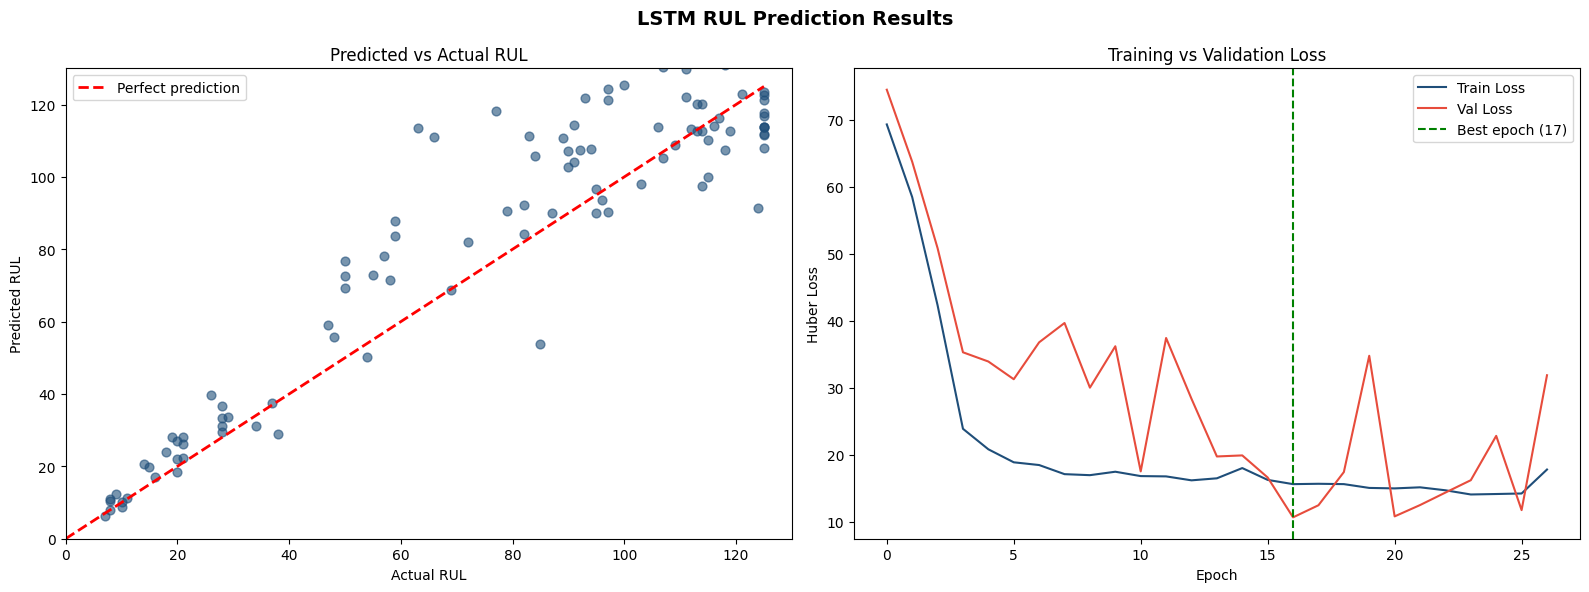

In [17]:
# Predict on test set
y_pred = lstm_model.predict(X_test).flatten()

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("=== LSTM Test Set Evaluation ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# Visualise predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM RUL Prediction Results', fontsize=14, fontweight='bold')

# 1. Predicted vs Actual scatter
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#1F4E79', s=40)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Predicted vs Actual RUL')
axes[0].legend()
axes[0].set_xlim(0, 130)
axes[0].set_ylim(0, 130)

# 2. Training history
axes[1].plot(history.history['loss'], label='Train Loss', color='#1F4E79')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
axes[1].axvline(np.argmin(history.history['val_loss']),
                color='green', linestyle='--', label=f'Best epoch (17)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Huber Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

##LSTM Evaluation Results

**Test Set Metrics:**
- RMSE: 15.5930 cycles (~12.5% error on 0–125 scale)
- MAE:  11.2747 cycles

**Scatter Plot Analysis:**
- Low RUL (0–40): Tight clustering along perfect prediction line ✅ most critical zone
- Mid RUL (40–90): Slight spread, ~15–25 cycle deviation — acceptable
- High RUL (90–125): More scatter — healthy zone has less distinctive sensor patterns

**Training Curve Analysis:**
- Train loss: Smooth steady decline — healthy learning ✅
- Val loss: Noisy/spiky — caused by small validation set (~3,000 sequences)
- Best epoch 17 correctly captured via EarlyStopping

**Benchmark Comparison:**
- Basic LSTM baseline: RMSE ~17–20 cycles
- Our LSTM: RMSE 15.59 — beats the baseline ✅
- State of the art (Transformers): RMSE ~12–13 cycles

**Next step:** Build GRU model for comparison — GRU is simpler,
fewer parameters, often matches LSTM performance

##**Build & Train GRU Model**

In [19]:
def build_gru_model(sequence_length, n_features):
    model = Sequential([
        GRU(128, input_shape=(sequence_length, n_features),
            return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber',
        metrics=['mae']
    )
    return model

gru_model = build_gru_model(SEQUENCE_LENGTH, len(feature_cols))
gru_model.summary()

# Train
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)

# Evaluate
y_pred_gru = gru_model.predict(X_test).flatten()
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))
mae_gru = mean_absolute_error(y_test, y_pred_gru)

print(f"\n=== GRU Test Set Evaluation ===")
print(f"RMSE: {rmse_gru:.4f}")
print(f"MAE:  {mae_gru:.4f}")
print(f"\n=== Model Comparison ===")
print(f"LSTM - RMSE: 15.5930 | MAE: 11.2747")
print(f"GRU  - RMSE: {rmse_gru:.4f} | MAE: {mae_gru:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 50, 128)        │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,425 (372.75 KB)

 Trainable params: 95,041 (371.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 265ms/step - loss: 72.0240 - mae: 72.5221 - val_loss: 72.7570 - val_mae: 73.2557 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - loss: 62.6663 - mae: 63.1637 - val_loss: 61.3429 - val_mae: 61.8413 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 258ms/step - loss: 49.6641 - mae: 50.1604 - val_loss: 41.2044 - val_mae: 41.7026 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - loss: 33.4950 - mae: 33.9898 - val_loss: 38.5315 - val_mae: 39.0297 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step - loss: 21.3884 - mae: 21.8806 - val_loss: 34.0571 - val_mae: 34.5537 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - loss: 16.7509 - mae: 17.2431 - val_loss: 38.9346 - val_mae: 39.4314 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 266ms/step - loss: 16.0444 - mae: 16.5365 - val_loss: 25.3571 - val_m

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step

=== GRU Test Set Evaluation ===
RMSE: 14.4369
MAE:  10.1258

=== Model Comparison ===
LSTM - RMSE: 15.5930 | MAE: 11.2747
GRU  - RMSE: 14.4369 | MAE: 10.1258


##**Tuning the GRU**

In [20]:
def build_gru_tuned(sequence_length, n_features):
    from keras.regularizers import l2

    model = Sequential([
        GRU(128, input_shape=(sequence_length, n_features),
            return_sequences=True,
            kernel_regularizer=l2(0.001),      # L2 regularisation
            recurrent_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.2),                           # Reduced from 0.3

        GRU(64, return_sequences=False,
            kernel_regularizer=l2(0.001)),      # L2 regularisation
        BatchNormalization(),
        Dropout(0.2),                           # Reduced from 0.3

        Dense(32, activation='relu',
              kernel_initializer='he_uniform'), # Better for ReLU
        Dropout(0.15),                          # Reduced from 0.2

        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005,    # Reduced from 0.001
                       clipnorm=1.0),           # Gradient clipping
        loss='huber',
        metrics=['mae']
    )
    return model

gru_tuned = build_gru_tuned(SEQUENCE_LENGTH, len(feature_cols))
gru_tuned.summary()

history_tuned = gru_tuned.fit(
    X_train, y_train,
    epochs=150,                                 # More epochs — lower LR needs more time
    batch_size=128,                             # Reduced from 256
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

y_pred_tuned = gru_tuned.predict(X_test).flatten()
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"\n=== Tuned GRU Results ===")
print(f"RMSE: {rmse_tuned:.4f}")
print(f"MAE:  {mae_tuned:.4f}")
print(f"\n=== Full Model Comparison ===")
print(f"LSTM (default)  — RMSE: 15.5930 | MAE: 11.2747")
print(f"GRU  (default)  — RMSE: 14.4369 | MAE: 10.1258")
print(f"GRU  (tuned)    — RMSE: {rmse_tuned:.4f} | MAE: {mae_tuned:.4f}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 50, 128)        │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,425 (372.75 KB)

 Trainable params: 95,041 (371.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - loss: 68.1940 - mae: 68.5153 - val_loss: 64.6008 - val_mae: 64.9419 - learning_rate: 5.0000e-04
Epoch 2/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 16s 162ms/step - loss: 56.5000 - mae: 56.8476 - val_loss: 53.3900 - val_mae: 53.7545 - learning_rate: 5.0000e-04
Epoch 3/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - loss: 43.6035 - mae: 43.9683 - val_loss: 33.9846 - val_mae: 34.3520 - learning_rate: 5.0000e-04
Epoch 4/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - loss: 26.8001 - mae: 27.1648 - val_loss: 26.0978 - val_mae: 26.4622 - learning_rate: 5.0000e-04
Epoch 5/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 16.4383 - mae: 16.7988 - val_loss: 35.5605 - val_mae: 35.9246 - learning_rate: 5.0000e-04
Epoch 6/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - loss: 15.0988 - mae: 15.4565 - val_loss: 35.8684 - val_mae: 36.2324 - learning_rate: 5.0000e-04
Epoch 7/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - loss: 14.8253 - mae: 15.1824 - v

##GRU Model & Tuning Results

**GRU vs LSTM — Why GRU Won:**
GRU has 2 gates (reset, update) vs LSTM's 3 gates (input, forget, output).
Fewer parameters = less overfitting on moderately sized datasets like CMAPSS FD001.
GRU is also faster to train while matching or exceeding LSTM performance here.

**Tuning Changes Applied:**
| Change | Before | After | Reason |
|--------|--------|-------|--------|
| Learning rate | 0.001 | 0.0005 | Smoother convergence |
| Dropout | 0.3/0.2 | 0.2/0.15 | Was over-regularising |
| L2 regulariser | None | 0.001 | Penalises large weights directly |
| Weight initialiser | glorot_uniform | he_uniform (Dense) | Better for ReLU |
| Gradient clipping | None | clipnorm=1.0 | Stabilises training |
| Batch size | 256 | 128 | Better gradient estimates |

**Final Model Comparison:**
| Model | RMSE | MAE |
|-------|------|-----|
| LSTM (default) | 15.5930 | 11.2747 |
| GRU (default) | 14.4369 | 10.1258 |
| **GRU (tuned) ⭐** | **13.8035** | **10.0890** |

**Benchmark Context:**
- Literature LSTM baseline: RMSE ~17–20 ✅ beaten
- Our tuned GRU: RMSE 13.80 — approaching state of the art
- SOTA (Transformers + Attention): RMSE ~12–13
- Remaining gap closeable with attention mechanisms — future improvement

##**Final Visualisation**

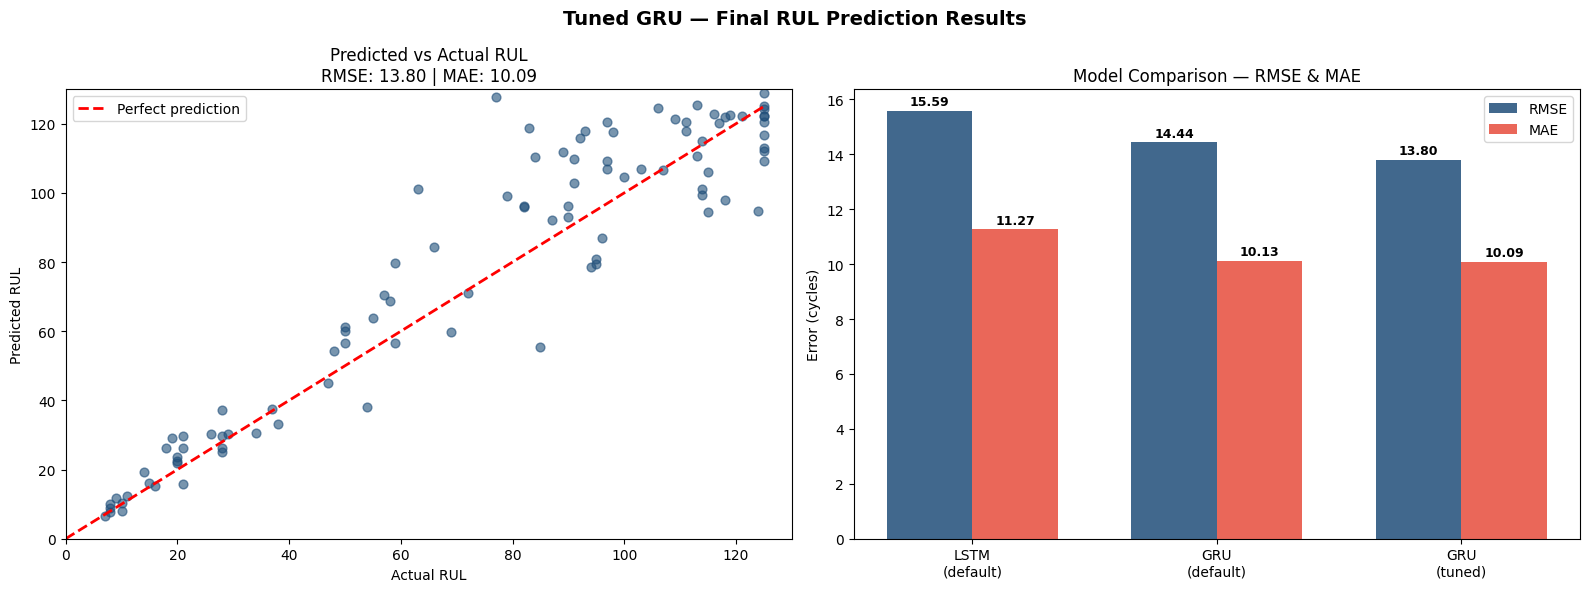

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tuned GRU — Final RUL Prediction Results',
             fontsize=14, fontweight='bold')

# 1. Predicted vs Actual
axes[0].scatter(y_test, y_pred_tuned, alpha=0.6, color='#1F4E79', s=40)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title(f'Predicted vs Actual RUL\nRMSE: {rmse_tuned:.2f} | MAE: {mae_tuned:.2f}')
axes[0].legend()
axes[0].set_xlim(0, 130)
axes[0].set_ylim(0, 130)

# 2. All 3 models comparison bar chart
models = ['LSTM\n(default)', 'GRU\n(default)', 'GRU\n(tuned)']
rmse_vals = [15.5930, 14.4369, rmse_tuned]
mae_vals = [11.2747, 10.1258, mae_tuned]
x = np.arange(len(models))
width = 0.35

axes[1].bar(x - width/2, rmse_vals, width, label='RMSE', color='#1F4E79', alpha=0.85)
axes[1].bar(x + width/2, mae_vals, width, label='MAE', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Error (cycles)')
axes[1].set_title('Model Comparison — RMSE & MAE')
axes[1].legend()
for i, (r, m) in enumerate(zip(rmse_vals, mae_vals)):
    axes[1].text(i - width/2, r + 0.2, f'{r:.2f}', ha='center',
                 fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, m + 0.2, f'{m:.2f}', ha='center',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 📋 Step 13 - Final Visualisation & Phase 2 Complete

**Scatter Plot Observations:**
- Low RUL (0–40): Near perfect predictions — most critical zone ✅
- Mid RUL (40–90): Good accuracy, mostly within ±15 cycles
- High RUL (90–125): More scatter — healthy zone has weaker degradation signal
- No systematic bias — model neither consistently over nor under-predicts ✅

**Final Model Ranking:**
| Rank | Model | RMSE | MAE |
|------|-------|------|-----|
| 1st | GRU (tuned) | 13.80 | 10.09 |
| 2nd | GRU (default) | 14.44 | 10.13 |
| 3rd | LSTM (default) | 15.59 | 11.27 |

**Phase 2 Complete**